# **Классификация**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.datasets import load_iris

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score, recall_score
from sklearn.metrics import f1_score, classification_report

**K-Nearest**

In [3]:
data = load_iris()

In [4]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
df = pd.DataFrame(data['data'],columns = data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


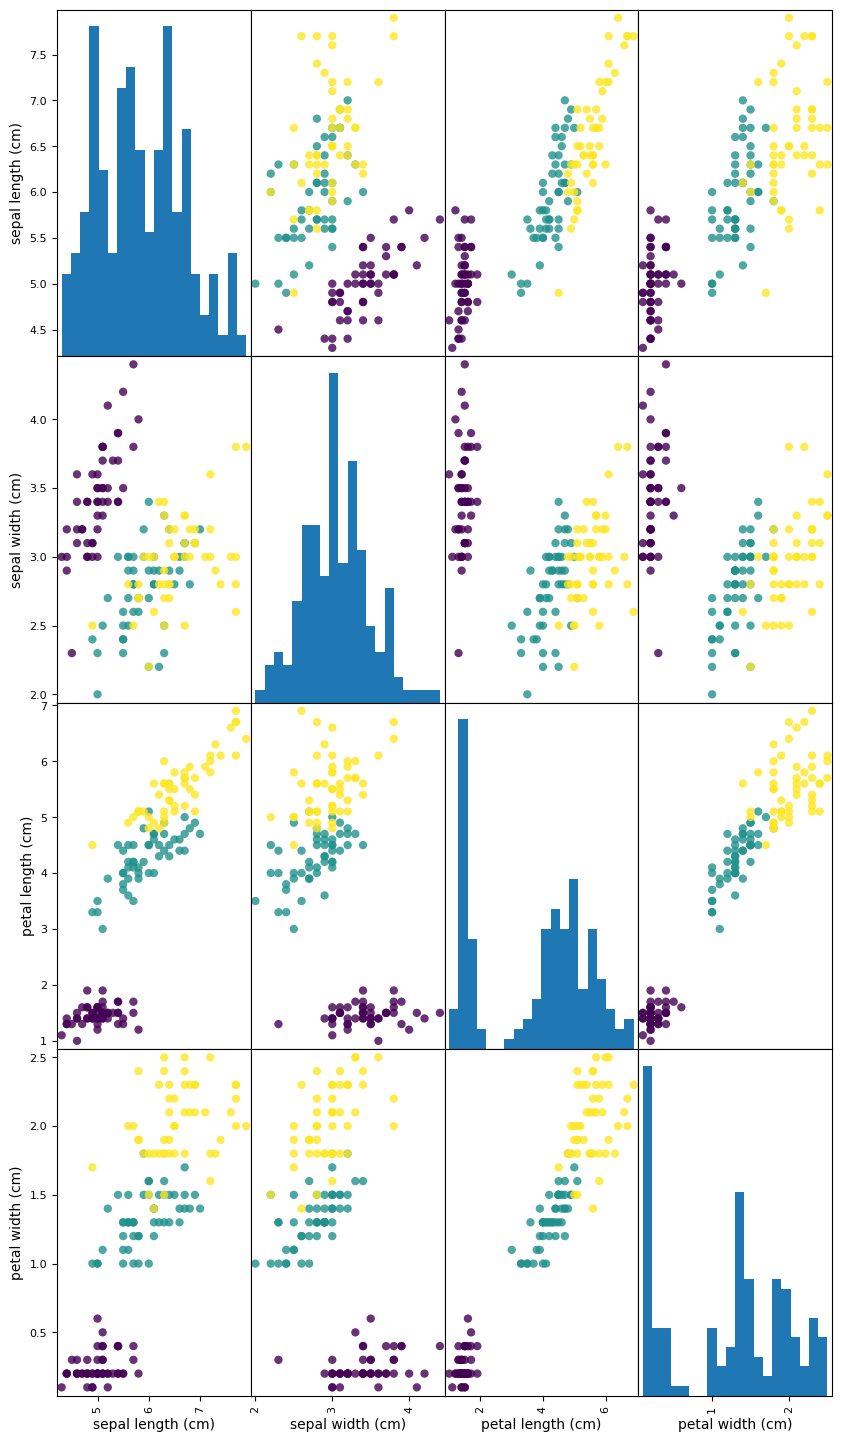

In [9]:
pd.plotting.scatter_matrix(df,c=data['target'],marker = 'o',
                           figsize = (10,18),hist_kwds={'bins':20},alpha = 0.8);

In [10]:
df_mini = pd.DataFrame(data.data[:,2:4],columns = data.feature_names[2:4])
df_mini.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [11]:
x_train,x_test,y_train,y_test = train_test_split(df_mini,
                                                 data['target'],test_size=0.25,
                                                 random_state=17)

In [12]:
x_train.shape

(112, 2)

In [13]:
y_train.shape

(112,)

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

KNeighborsClassifier()

In [15]:
knn_model = knn.fit(x_train,y_train)
knn_model

KNeighborsClassifier()

In [16]:
knn_predictions = knn.predict(x_test)
knn_predictions

array([0, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 1, 0, 2, 0, 0, 2, 2, 2, 1, 0,
       2, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 2])

In [17]:
accuracy_score(y_test,knn_predictions)

0.9736842105263158

In [18]:
predicted = knn.predict(df_mini)

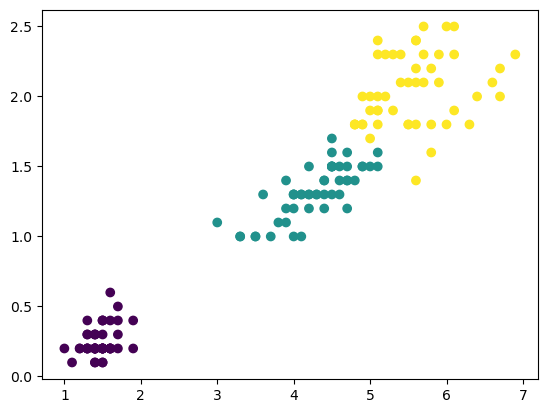

In [19]:
plt.scatter(df_mini['petal length (cm)'],df_mini['petal width (cm)'], c =predicted);

In [20]:
x_train,x_test,y_train,y_test = train_test_split(df,
                                                 data['target'],test_size=0.25,
                                                 random_state=17)

In [21]:
x_train.shape

(112, 4)

In [22]:
knn_full = KNeighborsClassifier(n_neighbors=5).fit(x_train,y_train)
knn_full_predictions = knn_full.predict(x_test)

In [23]:
accuracy_score(y_test,knn_full_predictions)

0.9473684210526315

### Наивный байесовский классификатор

In [26]:
nb = GaussianNB()
nb

GaussianNB()

In [27]:
nb.fit(x_train,y_train)

GaussianNB()

In [28]:
y_pred = nb.predict(x_test)
y_pred

array([0, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 1, 0, 2, 0, 0, 2, 2, 2, 1, 0,
       2, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 2])

In [29]:
accuracy_score(y_test,y_pred)

0.9736842105263158

### Логистическая регрессия

In [32]:
lg = LogisticRegression(solver = 'liblinear').fit(x_train,y_train)
lg

LogisticRegression(solver='liblinear')

In [33]:
lg_pred = lg.predict(x_test)

In [34]:
accuracy_score(y_test,lg_pred)

0.9210526315789473

### Метод опорных векторов

In [38]:
svc = SVC().fit(x_train,y_train)
svc

SVC()

In [40]:
svc_pred = svc.predict(x_test)

In [41]:
accuracy_score(y_test,svc_pred)

0.9736842105263158

### Деревья решений

In [43]:
cart = DecisionTreeClassifier().fit(x_train,y_train)
cart

DecisionTreeClassifier()

In [45]:
cart_pred = cart.predict(x_test)

In [46]:
accuracy_score(y_test,cart_pred)

0.9736842105263158

In [48]:
print(export_text(cart))

|--- feature_3 <= 0.80
|   |--- class: 0
|--- feature_3 >  0.80
|   |--- feature_3 <= 1.75
|   |   |--- feature_2 <= 5.35
|   |   |   |--- feature_3 <= 1.65
|   |   |   |   |--- feature_2 <= 4.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_2 >  4.95
|   |   |   |   |   |--- feature_2 <= 5.05
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- feature_2 >  5.05
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  1.65
|   |   |   |   |--- feature_0 <= 5.80
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- feature_0 >  5.80
|   |   |   |   |   |--- class: 1
|   |   |--- feature_2 >  5.35
|   |   |   |--- class: 2
|   |--- feature_3 >  1.75
|   |   |--- feature_2 <= 4.85
|   |   |   |--- feature_0 <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- feature_0 >  5.95
|   |   |   |   |--- class: 2
|   |   |--- feature_2 >  4.85
|   |   |   |--- class: 2



In [50]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strategies are "best" to 

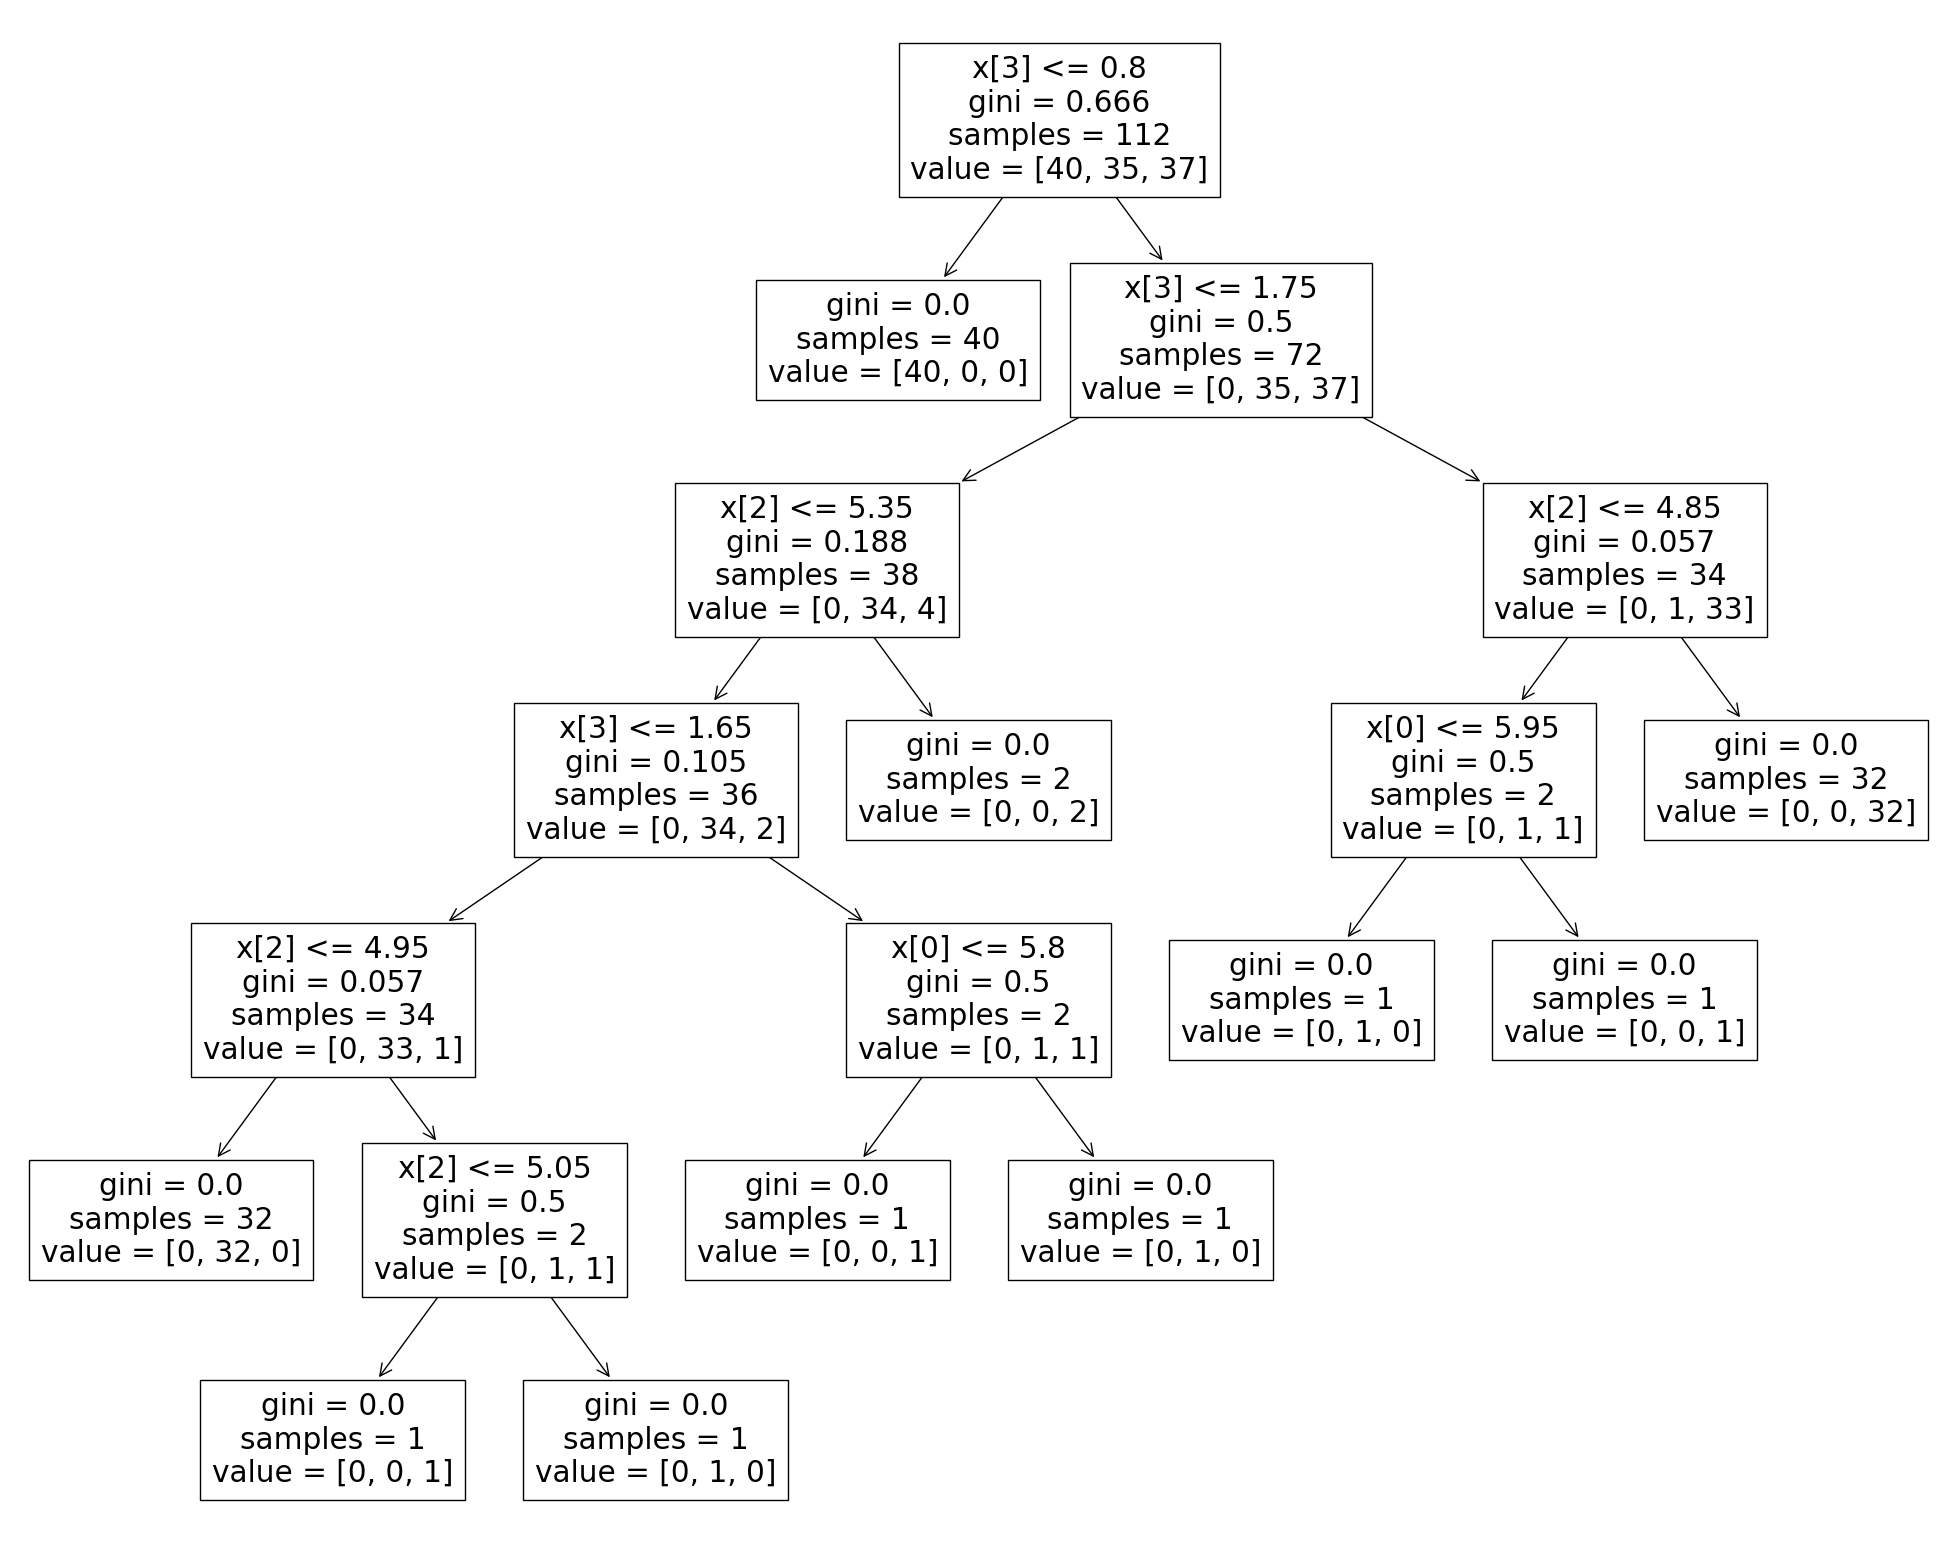

In [49]:
fig = plt.figure(figsize = (25,20))
plot_tree(cart);

In [3]:
from sklearn.datasets import load_wine
lw = load_wine()

In [4]:
lw.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [5]:
lw['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [6]:
lw['feature_names']

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [7]:
lw['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [8]:
df = pd.DataFrame(lw['data'], columns = lw['feature_names'])
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [9]:
df.shape

(178, 13)

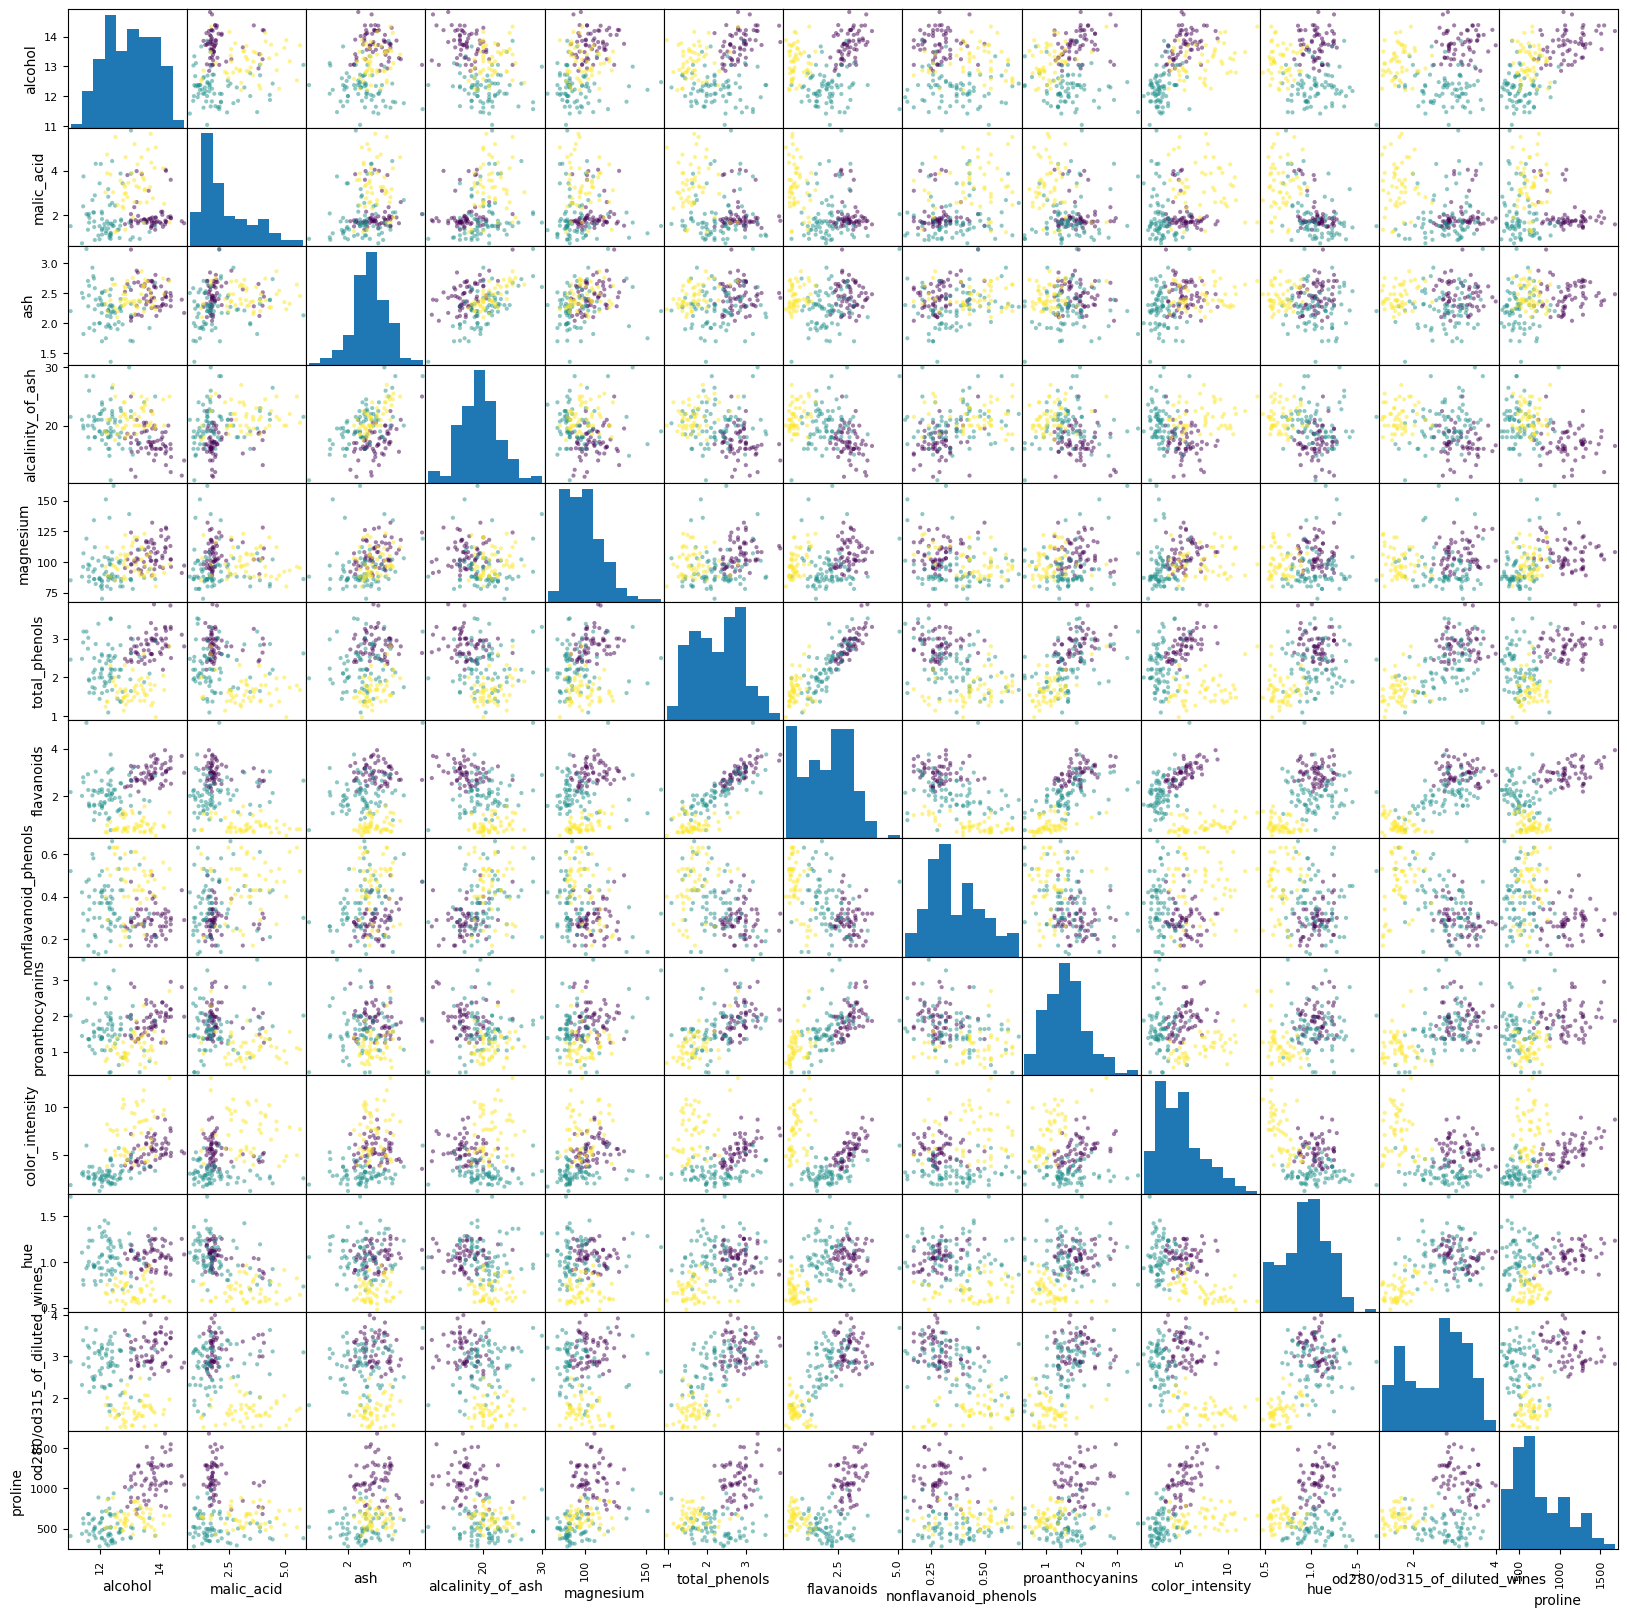

In [10]:
pd.plotting.scatter_matrix(df, c = lw['target'], figsize = (20,20));

In [11]:
X = df.values
y = lw['target']

In [12]:
kfold = KFold(n_splits=10, random_state = 7, shuffle = True)

In [13]:
model = DecisionTreeClassifier()

In [14]:
results = cross_val_score(model, X,y, cv = kfold, scoring = 'accuracy')

In [15]:
results

array([0.88888889, 0.94444444, 0.88888889, 1.        , 0.88888889,
       0.94444444, 0.88888889, 0.83333333, 0.88235294, 0.82352941])

In [16]:
results.mean()

0.8983660130718955

In [17]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 7)

In [18]:
cart = DecisionTreeClassifier().fit(x_train,y_train)

In [19]:
accuracy_score(y_test, cart.predict(x_test))

0.9444444444444444

In [20]:
models = []
models.append(('knn',KNeighborsClassifier()))
models.append(('logreg',LogisticRegression(solver = 'liblinear')))
models.append(('svc', SVC()))
models.append(('gb',GaussianNB()))
models.append(('cart',DecisionTreeClassifier()))

In [21]:
models

[('knn', KNeighborsClassifier()),
 ('logreg', LogisticRegression(solver='liblinear')),
 ('svc', SVC()),
 ('gb', GaussianNB()),
 ('cart', DecisionTreeClassifier())]

In [22]:
for name,model in models:
    result = cross_val_score(model, X,y, cv = kfold, scoring = 'accuracy')
    print(f'name:{name} - accuracy:{result.mean()}')

name:knn - accuracy:0.7124183006535948
name:logreg - accuracy:0.9601307189542483
name:svc - accuracy:0.6911764705882353
name:gb - accuracy:0.977124183006536
name:cart - accuracy:0.8875816993464053


In [23]:
model = GaussianNB().fit(x_train,y_train)
y_pred = model.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

### Матрица ошибки

In [25]:
confusion_matrix(y_test,y_pred)

array([[ 7,  0,  0],
       [ 0, 17,  0],
       [ 0,  0, 12]])

In [26]:
cart = DecisionTreeClassifier().fit(x_train,y_train)
y_pred_cart = cart.predict(x_test)
accuracy_score(y_test,y_pred_cart)

0.9166666666666666

In [27]:
confusion_matrix(y_test,y_pred_cart)

array([[ 7,  0,  0],
       [ 1, 16,  0],
       [ 1,  1, 10]])

## Метрики качества

### Precision (Точность)

In [30]:
precision_score (y_test,y_pred_cart, average= 'weighted')

0.9290123456790123

### Recall (Полнота)

In [33]:
recall_score(y_test,y_pred_cart, average= 'weighted')

0.9166666666666666

### F-мера

In [35]:
f1_score(y_test,y_pred_cart, average= 'weighted')

0.9176136363636362

In [38]:
print(classification_report(y_test,y_pred_cart))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       0.94      0.94      0.94        17
           2       1.00      0.83      0.91        12

    accuracy                           0.92        36
   macro avg       0.91      0.92      0.91        36
weighted avg       0.93      0.92      0.92        36

